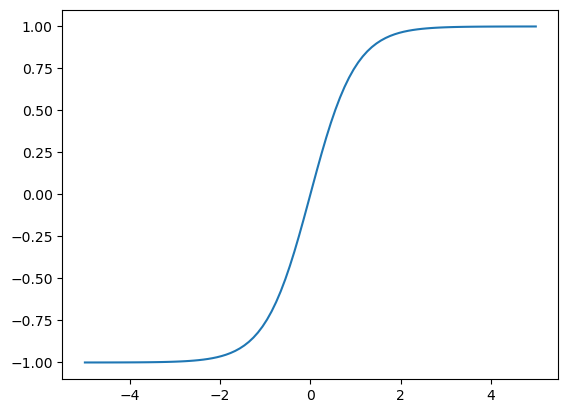

In [ ]:
# RNN => 순환신경망
# sigmoid, relu, tanh
import numpy as np
import matplotlib.pyplot as plt

# -5부터 5까지 순차적으로 100개 생성
x = np.linspace(-5, 5, 100)
y = np.tanh(x)

plt.plot(x,y)

In [ ]:
inputs = [1, 2, 3]

# 초기 hidden 값
h = 0

for step, x in enumerate(inputs, start=1):
    h = np.tanh(x+h)
    print(f"{step}:{h}")

1:0.7615941559557649
2:0.9920455700292888
3:0.9993185480009414


In [ ]:
# 다음 숫자예측
import numpy as np

x = []
y = []

for i in range(6):
    lst = np.array(range(i,i+4)) / 10
    lst = lst.reshape(-1, 1)

    x.append(lst)
    y.append((i+4)/10)

x, y

([array([[0. ],
         [0.1],
         [0.2],
         [0.3]]),
  array([[0.1],
         [0.2],
         [0.3],
         [0.4]]),
  array([[0.2],
         [0.3],
         [0.4],
         [0.5]]),
  array([[0.3],
         [0.4],
         [0.5],
         [0.6]]),
  array([[0.4],
         [0.5],
         [0.6],
         [0.7]]),
  array([[0.5],
         [0.6],
         [0.7],
         [0.8]])],
 [0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

In [ ]:
x = np.array(x)
y = np.array(y)
# RNN (n, timestamp, feature)
x.shape, y.shape

((6, 4, 1), (6,))

In [18]:
import tensorflow as tf
from tensorflow.keras import layers

model = tf.keras.Sequential([
    layers.Input(shape=(4,1)),
    # (1*10) + (10*10) + 10 = 120
    layers.SimpleRNN(units=10, activation="tanh", return_sequences=True),
    # (10*10) + (10*10) + 10 = 210
    layers.SimpleRNN(units=10, activation="relu", return_sequences=False),
    layers.Dense(units=1, activation="linear")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 4, 10)          │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 341 (1.33 KB)

 Trainable params: 341 (1.33 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [20]:
model.fit(x, y, epochs=1000, verbose=2)

Epoch 1/1000
1/1 - 1s - 1s/step - loss: 1.9572 - mae: 1.3147
Epoch 2/1000
1/1 - 0s - 32ms/step - loss: 1.8096 - mae: 1.2621
Epoch 3/1000
1/1 - 0s - 32ms/step - loss: 1.6688 - mae: 1.2100
Epoch 4/1000
1/1 - 0s - 33ms/step - loss: 1.5343 - mae: 1.1587
Epoch 5/1000
1/1 - 0s - 31ms/step - loss: 1.4086 - mae: 1.1098
Epoch 6/1000
1/1 - 0s - 32ms/step - loss: 1.2911 - mae: 1.0621
Epoch 7/1000
1/1 - 0s - 33ms/step - loss: 1.1817 - mae: 1.0158
Epoch 8/1000
1/1 - 0s - 35ms/step - loss: 1.0794 - mae: 0.9706
Epoch 9/1000
1/1 - 0s - 33ms/step - loss: 0.9849 - mae: 0.9273
Epoch 10/1000
1/1 - 0s - 33ms/step - loss: 0.8969 - mae: 0.8853
Epoch 11/1000
1/1 - 0s - 33ms/step - loss: 0.8146 - mae: 0.8439
Epoch 12/1000
1/1 - 0s - 32ms/step - loss: 0.7374 - mae: 0.8032
Epoch 13/1000
1/1 - 0s - 33ms/step - loss: 0.6707 - mae: 0.7673
Epoch 14/1000
1/1 - 0s - 32ms/step - loss: 0.6173 - mae: 0.7372
Epoch 15/1000
1/1 - 0s - 32ms/step - loss: 0.5713 - mae: 0.7100
Epoch 16/1000
1/1 - 0s - 33ms/step - loss: 0.5282 -

In [21]:
from sklearn.metrics import r2_score
y_pred = model.predict(x)

r2_score(y, y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


0.9956205270324329

In [22]:
# (n, step, feature)
sample = np.array([[[0.5],[0.6],[0.7],[0.8]]])
sample.shape

(1, 4, 1)

In [23]:
# 예측값
model.predict(sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


array([[0.8834201]], dtype=float32)